# Figure 2: Chromatin vs Gene Expression

**Goal:**
Compute chromatin metrics for each gene and show relationship with gene expression.

**Procedure**
1. Compute: +1 nucleosome shift, gene body entropy, promoter occupancy.
2. Compute PTRs for each and compare to gene expression PTR
3. Compute thresholds to select genes with chromatin and gene expression changes.
4. Show examples of each.
(5). Plot the time course of some of these genes with the arrow plot.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from src.Figure3_chromatin_metrics import Figure3ChromatinMetrics

figure3 = Figure3ChromatinMetrics()

Shape of the loaded F: (178, 340)
Shape of the adjusted F shape: (178, 374)
1/5578 - 00:00:00.118
1001/5578 - 00:00:08.194
2001/5578 - 00:00:15.947
3001/5578 - 00:00:24.000
4001/5578 - 00:00:31.979
5001/5578 - 00:00:45.094


In [3]:
figure3.track_img('CLB5')

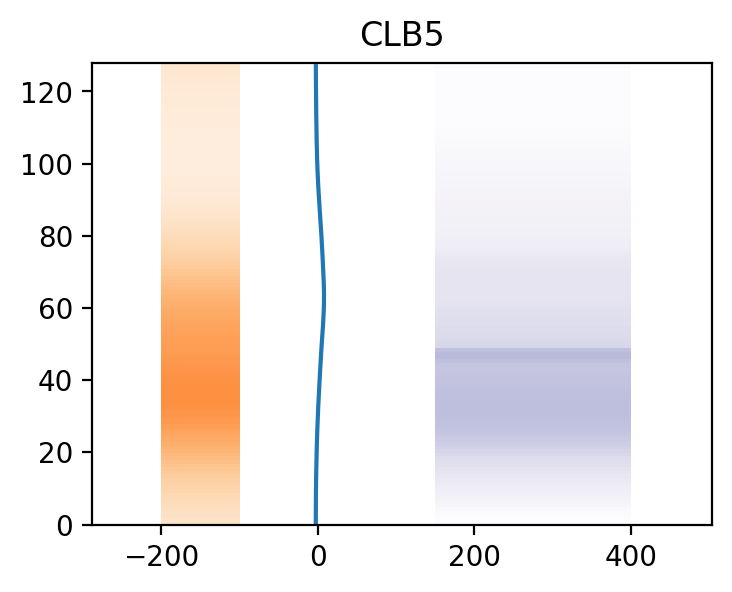

In [4]:
figure3.plot_tracking()

In [5]:
from src.deconv_data import load_gene_expression_fs
gene_expression_f = load_gene_expression_fs('output/deconvolve_sharedg1_0066_cc_2024_06_13/gene_expression/')

In [6]:
from src.timer import Timer

timer = Timer()

all_df = pd.DataFrame()
i = 0
for orf_name, gene in figure3.genes.iterrows():

    current_gene_expression = gene_expression_f.loc[orf_name]
        
    figure3.track_img(orf_name)
    current_df = figure3.tracking_df.reset_index()
    current_df['orf_name'] = figure3.gene.name
    current_df['gene_expression'] = current_gene_expression
    
    all_df = pd.concat([all_df, current_df])

    if i % 100 == 0:
        timer.print_time(f"{i}/{len(figure3.genes)}")

    i += 1


0/5578 - 00:00:00.106
100/5578 - 00:00:04.590
200/5578 - 00:00:09.139
300/5578 - 00:00:13.874
400/5578 - 00:00:18.457
500/5578 - 00:00:24.039
600/5578 - 00:00:29.282
700/5578 - 00:00:34.775
800/5578 - 00:00:40.155
900/5578 - 00:00:45.767
1000/5578 - 00:00:50.952
1100/5578 - 00:00:55.965
1200/5578 - 00:01:00.958
1300/5578 - 00:01:05.456
1400/5578 - 00:01:10.460
1500/5578 - 00:01:15.964
1600/5578 - 00:01:21.683
1700/5578 - 00:01:27.949
1800/5578 - 00:01:34.459
1900/5578 - 00:01:40.575
2000/5578 - 00:01:46.243
2100/5578 - 00:01:51.593
2200/5578 - 00:01:57.344
2300/5578 - 00:02:02.442
2400/5578 - 00:02:07.461
2500/5578 - 00:02:12.389
2600/5578 - 00:02:17.776
2700/5578 - 00:02:22.685
2800/5578 - 00:02:27.763
2900/5578 - 00:02:32.899
3000/5578 - 00:02:38.059
3100/5578 - 00:02:43.251
3200/5578 - 00:02:48.746
3300/5578 - 00:02:53.935
3400/5578 - 00:02:59.999
3500/5578 - 00:03:06.087
3600/5578 - 00:03:11.889
3700/5578 - 00:03:18.082
3800/5578 - 00:03:23.516
3900/5578 - 00:03:30.123
4000/5578 - 

In [7]:
# Append the gene expression values and compute PTRs for each gene
# The scatter plot each metric against gene expression

In [10]:
from src.config import load_configs_by_config_type

config1, config2 = load_configs_by_config_type('shared')
t_indices = config1.get_Hpositions_for_branch('t')

In [42]:
from src.peak_to_trough import compute_quantile_ptr


timer = Timer()
gene_ptrs_df = figure3.genes[[]].copy()
all_genes_df = all_df.set_index(['orf_name', 'H_index'])
    
i = 0
for orf_name, row in gene_ptrs_df.iterrows():
    # Compute peak to trough ratios for each gene for each metric

    gene_df = all_genes_df.loc[orf_name]

    for metric in gene_df.columns:
        ptr = compute_quantile_ptr(gene_df[metric][t_indices])
        gene_ptrs_df.loc[orf_name, metric] = ptr
        
    if i % 100 == 0:
        timer.print_time(f"{i}/{len(figure3.genes)}")

    i += 1


0/5578 - 00:00:00.184
100/5578 - 00:00:00.462
200/5578 - 00:00:00.741
300/5578 - 00:00:01.041
400/5578 - 00:00:01.321
500/5578 - 00:00:01.605
600/5578 - 00:00:01.880
700/5578 - 00:00:02.151
800/5578 - 00:00:02.430
900/5578 - 00:00:02.710
1000/5578 - 00:00:02.980
1100/5578 - 00:00:03.252
1200/5578 - 00:00:03.523
1300/5578 - 00:00:03.794
1400/5578 - 00:00:04.065
1500/5578 - 00:00:04.338
1600/5578 - 00:00:04.606
1700/5578 - 00:00:04.884
1800/5578 - 00:00:05.161
1900/5578 - 00:00:05.436
2000/5578 - 00:00:05.709
2100/5578 - 00:00:05.981
2200/5578 - 00:00:06.252
2300/5578 - 00:00:06.524
2400/5578 - 00:00:06.798
2500/5578 - 00:00:07.091
2600/5578 - 00:00:07.373
2700/5578 - 00:00:07.648
2800/5578 - 00:00:07.924
2900/5578 - 00:00:08.214
3000/5578 - 00:00:08.496
3100/5578 - 00:00:08.770
3200/5578 - 00:00:09.047
3300/5578 - 00:00:09.321
3400/5578 - 00:00:09.587
3500/5578 - 00:00:09.858
3600/5578 - 00:00:10.132
3700/5578 - 00:00:10.409
3800/5578 - 00:00:10.681
3900/5578 - 00:00:10.946
4000/5578 - 

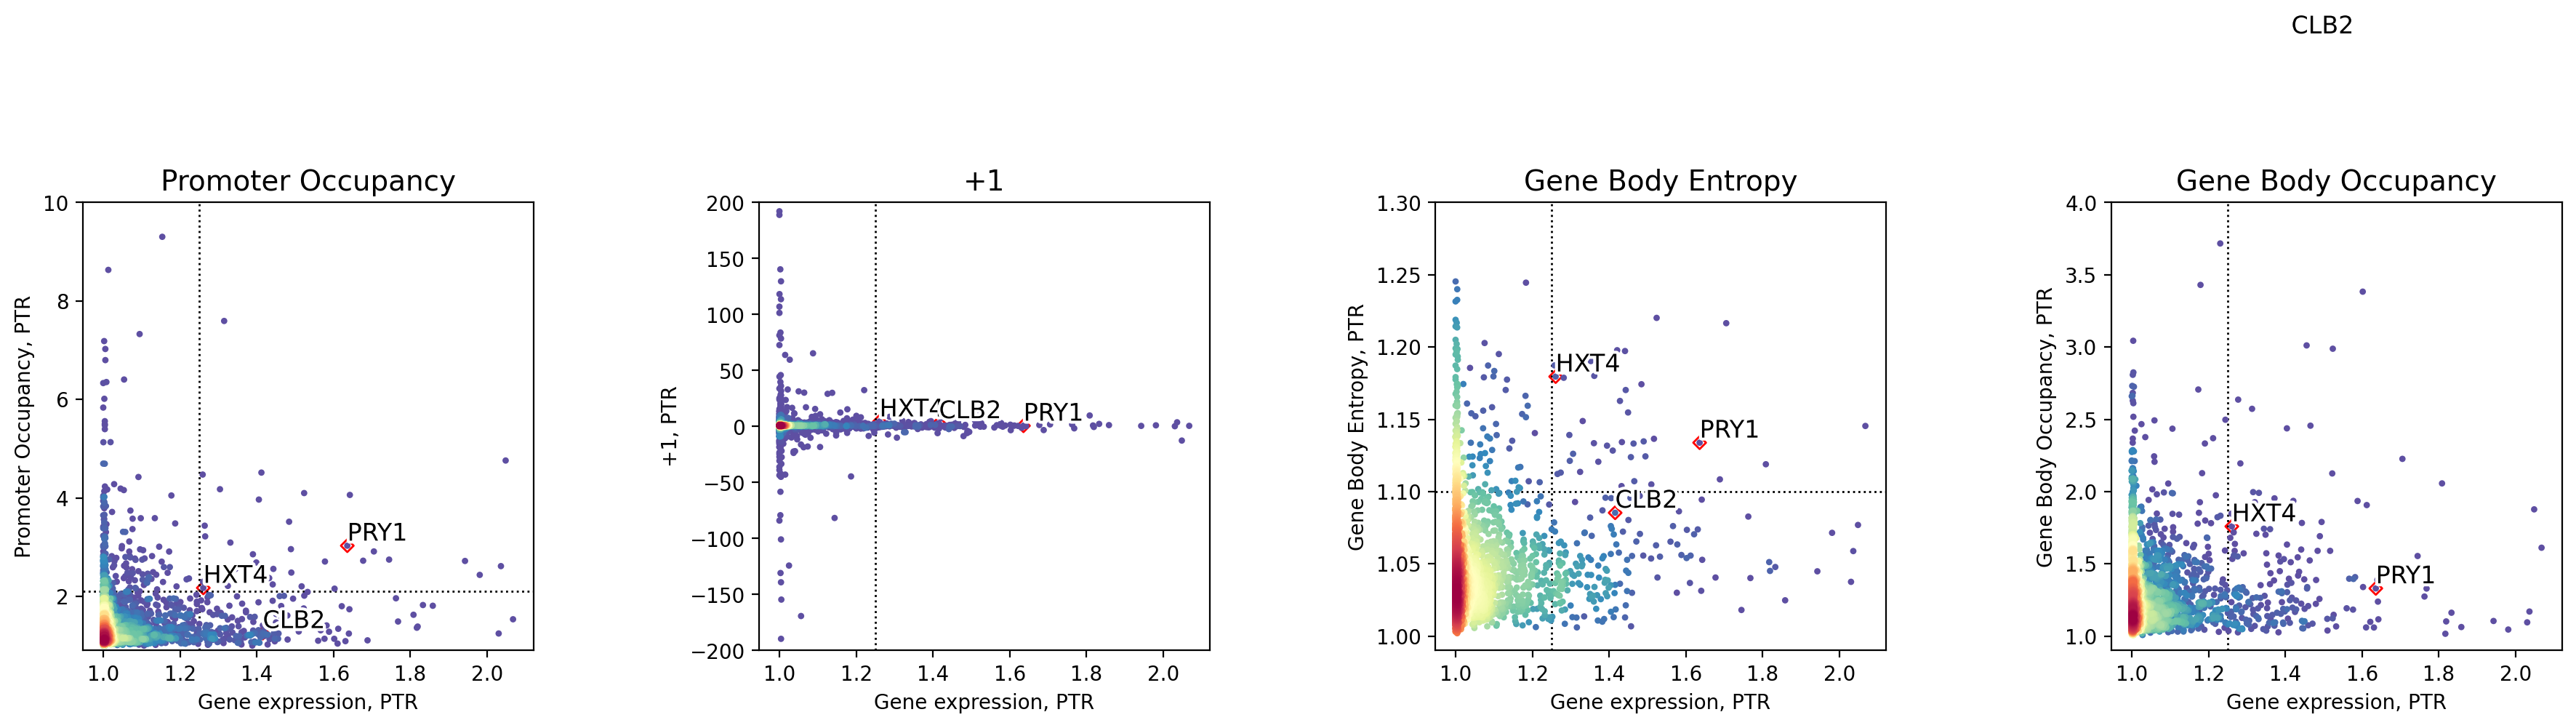

In [117]:
from src.figure_configs import FiguresConfig, save_figure_for_paper
from src.DensityScatterPlotter import DensityScatterPlotter
from src.sgd import get_gene_name_orf_name

chromatin_columns = gene_ptrs_df.columns[:-1]
cols = len(chromatin_columns)

cutoffs = [2.1, None, 1.1, None]
ylims = [
    (0.9, 10),
    (-200, 200),
    (0.99, 1.3),
    (0.9, 4),
]

import matplotlib.patheffects as path_effects

selected_genes = ['PRY1', 'HXT4', 'CLB2']

plt.figure(figsize=(22, 4))
plt.subplots_adjust(wspace=0.5)
for i in range(cols):
    plt.subplot(1, cols, i+1)
    column = chromatin_columns[i]
    chrom_dat = gene_ptrs_df[column]
    ge_dat = gene_ptrs_df['gene_expression']
    #plt.scatter(ge_dat, chrom_dat, s=1)
    plt.title(f"{column.replace('_', ' ').title()}", 
              fontsize=FiguresConfig.FIG_TITLE_FONTSIZE)
    plt.ylabel(column.replace('_', ' ').title()+ ", PTR")
    plt.xlabel("Gene expression, PTR")
    plt.ylim(ylims[i])
    if cutoffs[i] is not None:
        plt.axhline(cutoffs[i], c='black', ls='dotted', lw=1)
    plt.axvline(1.25, c='black', ls='dotted', lw=1)
    
    from src.DensityScatterPlotter import DensityScatterPlotter
    ax = plt.gca()
    g_density_plotter = DensityScatterPlotter()
    g_density_plotter.cmap='Spectral_r'
    g_density_plotter.bw = (0.01, 0.01)

    x, y = ge_dat, chrom_dat
    g_density_plotter.logz = True
    g_density_plotter.set_data(x, y)
    g_density_plotter.plot_ax(ax)


    for gene in selected_genes:
        orf_name, gene_name = get_gene_name_orf_name(gene)
        x, y = ge_dat.loc[orf_name], chrom_dat.loc[orf_name]
        plt.scatter(x, y, s=20, facecolor='none', edgecolor='red', lw=1, marker='D')
        text = plt.text(x, y, gene_name, ha='left', va='bottom', fontsize=12)
        text.set_path_effects([path_effects.Stroke(linewidth=3, foreground='white'),
        path_effects.Normal()])

save_figure_for_paper("output/ISMB_2024/Chromatin_metrics.png")


In [33]:
# +1 needs to be adjusted, the PTR calculation to ensure values are above 0....
# think about the proper way to handle this

# Then threshold each of the four metrics
# And identify overlap to find some interesting genes...

In [129]:
selected_genes = gene_ptrs_df[(gene_ptrs_df['promoter_occupancy'] > cutoffs[0]) & 
            (gene_ptrs_df['gene_body_entropy'] > cutoffs[2])].join(figure3.genes[['gene']])
print(len(selected_genes))
selected_genes.sort_values('promoter_occupancy')

24


,promoter_occupancy,+1,gene_body_entropy,gene_body_occupancy,gene_expression,gene
orf_name,,,,,,
YMR009W,2.101484,1.410907,1.158353,2.055402,1.095064,ADI1
YHR081W,2.132082,3.535147,1.141029,1.311596,1.002688,LRP1
YOL166W-A,2.139160,9.525996,1.517263,2.214760,1.000047,YOL166W-A
YHR092C,2.171706,4.480880,1.179545,1.758713,1.260707,HXT4
YNL331C,2.189736,1.361943,1.132708,1.212008,1.003974,AAD14
YER070W,2.203533,1.157448,1.136494,1.589526,1.516881,RNR1
YMR309C,2.279278,-0.133941,1.127442,1.740379,1.003550,NIP1
YNL015W,2.291812,-0.664641,1.107448,1.415206,1.155771,PBI2
YDL097C,2.312072,-5.043480,1.245369,1.407070,1.000051,RPN6
